# Decision tree using ID3

Feature 0 Information Gain = 0.3219
Feature 1 Information Gain = 0.0955
Feature 2 Information Gain = 0.1245
Feature 1 Information Gain = 0.8113
Feature 2 Information Gain = 0.8113
Feature 1 Information Gain = 0.3113
Feature 2 Information Gain = 0.1226
Feature 2 Information Gain = 0.0

Decision Tree:
{'feature': 0, 'branches': {'Overcast': 'Yes', 'Sunny': {'feature': 1, 'branches': {'Cool': 'Yes', 'Mild': 'No', 'Hot': 'No'}}, 'Rain': {'feature': 1, 'branches': {'Cool': {'feature': 2, 'branches': {'Normal': 'Yes'}}, 'Mild': 'Yes'}}}}

Actual values:
['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']

Predicted values:
['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes']

Correct Predictions = 9
Total Predictions = 10
Accuracy = 90.0 %


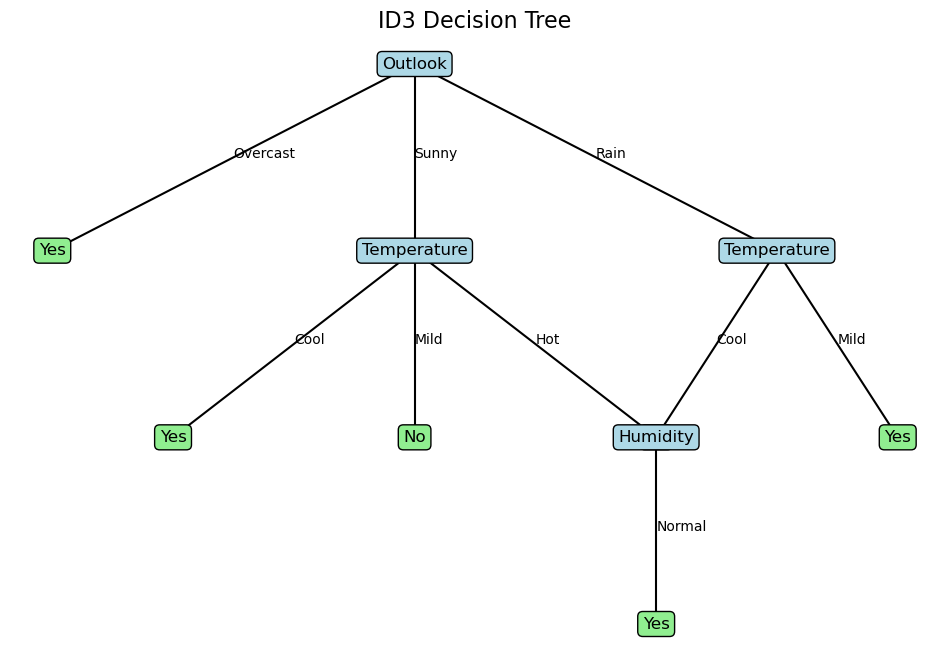

In [2]:
import math
from collections import Counter
import matplotlib.pyplot as plt



X = [
    ["Sunny", "Hot", "High"],
    ["Sunny", "Hot", "High"],
    ["Overcast", "Hot", "High"],
    ["Rain", "Mild", "High"],
    ["Rain", "Cool", "Normal"],
    ["Rain", "Cool", "Normal"],
    ["Overcast", "Cool", "Normal"],
    ["Sunny", "Mild", "High"],
    ["Sunny", "Cool", "Normal"],
    ["Rain", "Mild", "Normal"]
]

y = [
    "No",
    "No",
    "Yes",
    "Yes",
    "Yes",
    "No",
    "Yes",
    "No",
    "Yes",
    "Yes"
]



def entropy(labels):

    count = Counter(labels)
    total = len(labels)

    result = 0

    for value in count.values():

        probability = value / total

        result -= probability * math.log2(probability)

    return result




def information_gain(X, y, feature_index):

    total_entropy = entropy(y)

    values = set(row[feature_index] for row in X)

    weighted_entropy = 0

    for value in values:

        subset_y = []

        for i in range(len(X)):

            if X[i][feature_index] == value:
                subset_y.append(y[i])

        weight = len(subset_y) / len(y)

        weighted_entropy += weight * entropy(subset_y)

    return total_entropy - weighted_entropy




def best_feature(X, y, features):

    best_gain = -1
    best_index = None

    for index in features:

        gain = information_gain(X, y, index)

        print(
            "Feature",
            index,
            "Information Gain =",
            round(gain, 4)
        )

        if gain > best_gain:

            best_gain = gain
            best_index = index

    return best_index




def id3(X, y, features):

   
    if len(set(y)) == 1:
        return y[0]

   
    if len(features) == 0:
        return Counter(y).most_common(1)[0][0]

    best = best_feature(X, y, features)

    tree = {
        "feature": best,
        "branches": {}
    }

    values = set(row[best] for row in X)

    for value in values:

        subset_X = []
        subset_y = []

        for i in range(len(X)):

            if X[i][best] == value:

                subset_X.append(X[i])
                subset_y.append(y[i])

        remaining_features = [
            f for f in features if f != best
        ]

        tree["branches"][value] = id3(
            subset_X,
            subset_y,
            remaining_features
        )

    return tree


def predict(tree, row):

    # Leaf node
    if not isinstance(tree, dict):
        return tree

    feature = tree["feature"]

    value = row[feature]

    if value in tree["branches"]:

        return predict(
            tree["branches"][value],
            row
        )

    # Default prediction
    return "No"


features = [0, 1, 2]

tree = id3(X, y, features)

print("\nDecision Tree:")
print(tree)


predictions = []

for row in X:

    prediction = predict(tree, row)

    predictions.append(prediction)


print("\nActual values:")
print(y)

print("\nPredicted values:")
print(predictions)



correct = 0

for i in range(len(y)):

    if y[i] == predictions[i]:

        correct += 1


accuracy = (correct / len(y)) * 100

print("\nCorrect Predictions =", correct)
print("Total Predictions =", len(y))
print("Accuracy =", accuracy, "%")



feature_names = [
    "Outlook",
    "Temperature",
    "Humidity"
]


def draw_tree(tree, x=0.5, y=1.0, dx=0.25, parent=None, edge_label=""):

  
    if not isinstance(tree, dict):

        plt.text(
            x,
            y,
            tree,
            ha="center",
            va="center",
            fontsize=12,
            bbox=dict(
                boxstyle="round",
                facecolor="lightgreen",
                edgecolor="black"
            )
        )

        if parent is not None:

            plt.plot(
                [parent[0], x],
                [parent[1], y],
                "k-"
            )

            plt.text(
                (parent[0] + x) / 2,
                (parent[1] + y) / 2,
                edge_label,
                fontsize=10
            )

        return

   
    feature = tree["feature"]

    plt.text(
        x,
        y,
        feature_names[feature],
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(
            boxstyle="round",
            facecolor="lightblue",
            edgecolor="black"
        )
    )

    if parent is not None:

        plt.plot(
            [parent[0], x],
            [parent[1], y],
            "k-"
        )

        plt.text(
            (parent[0] + x) / 2,
            (parent[1] + y) / 2,
            edge_label,
            fontsize=10
        )

    branches = list(tree["branches"].items())

    n = len(branches)

    for i, (value, child) in enumerate(branches):

        child_x = x + (i - (n - 1) / 2) * dx

        child_y = y - 0.2

        draw_tree(
            child,
            child_x,
            child_y,
            dx / 1.5,
            (x, y),
            str(value)
        )


plt.figure(figsize=(12, 8))

draw_tree(tree)

plt.title(
    "ID3 Decision Tree",
    fontsize=16
)

plt.axis("off")

plt.show()
